# Testing the Fast OpenMM Cyclic Peptide Optimiser
This notebook tests the updated `CyclicPeptideOptimiser` which runs purely in OpenMM to avoid expensive side-chain packing and PDB roundtripping during the conformational search.

In [1]:
import sys
import time
from isambard.optimisation.cyclic_peptide_optimiser import CyclicPeptideOptimiser
from openmm.app import PDBFile
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Targets identified from the original notebook
macs = {
    7.1: 'TkNDTnp',
    7.2: 'hPdqseP',
    7.3: 'QDPpKtd',
    8.1: 'DDPTprQq',
    8.2: 'rQpqRePQ',
    9.1: 'pPYhPKDLq',
    10.1: 'PEAARvpRlt',
    10.2: 'EvDPehpNap'
}

pdbs = {
    7.1: '6be9',
    7.2: '6bew',
    7.3: '6bf5',
    8.1: '6be7',
    8.2: '6ben',
    9.1: '6beo',
    10.1: '6beq',
    10.2: '6ber'
}


Optimising 6be9 (Sequence: TkNDTnp)
Building starting macrocycle (this may take a moment for rand_mac to close the loop)...
Starting rmsd is 1.7231944462217508
At iter 14100 best rmsd is 0.05018919451052829))
After 14112 iterations and 0 attempts best rmsd is 0.0495684911418055
Setting up OpenMM context...
Running optimisation for 100 iterations...
optimising sequence TkNDTnp
 HOF at iter 99 is [-1221.1101353168488, -1205.385572731495, -1203.2347255945206, -1202.172303557396, -1201.7206146717072, -1196.8491806387901, -1195.8363706469536, -1192.4851497411728, -1188.9338483214378, -1188.6179511547089] best -1221.1101353168488 worst -939.8516101837158 rama 80.13333333333338                                                                                                        
Finished 6be9 in 253.32 seconds.
Initial energy: -1092.56
Best energy achieved: -1221.11


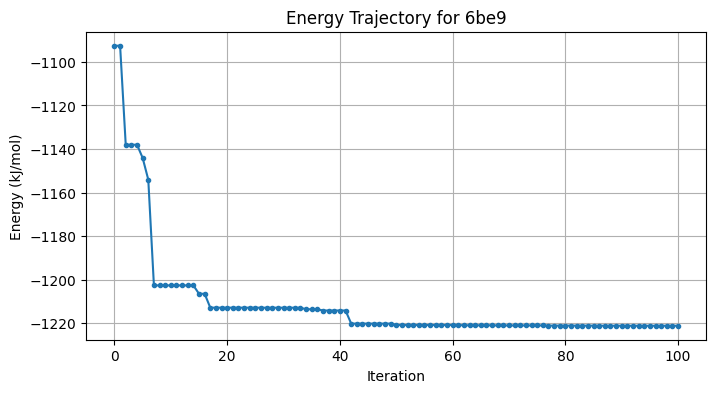

Plotting Ramachandran coordinates for Hall of Fame...


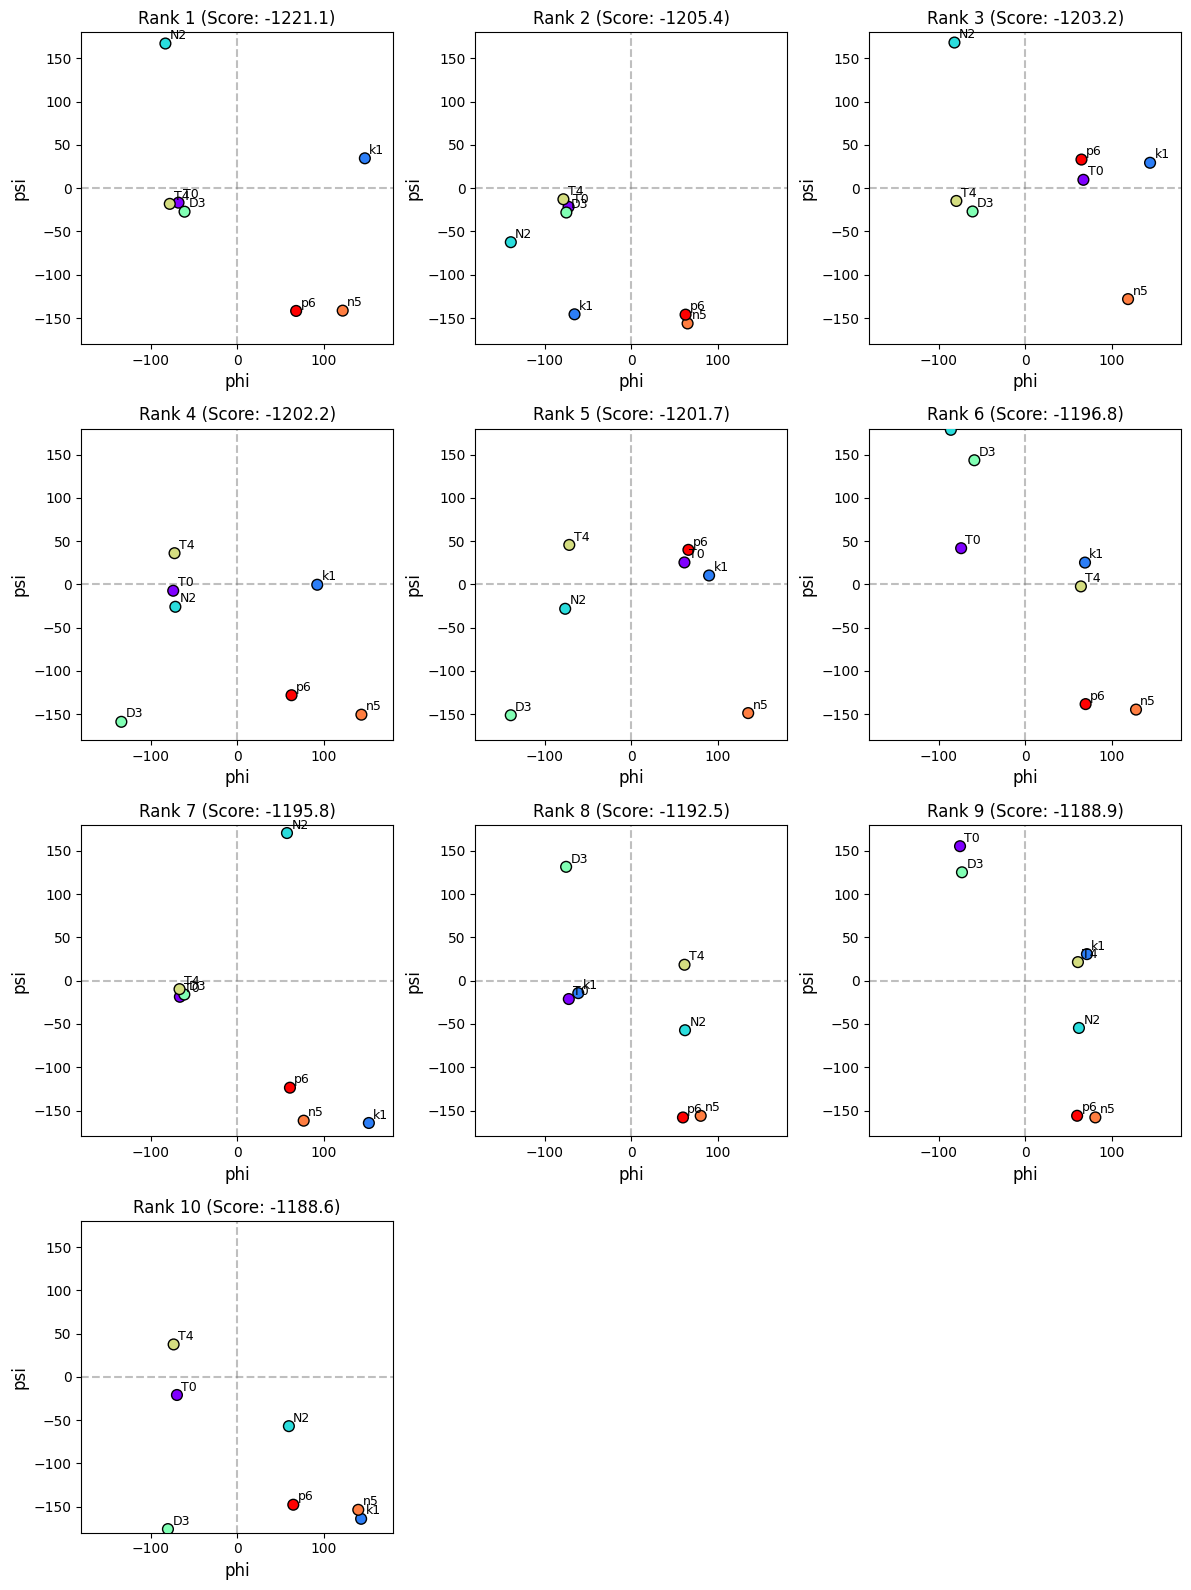

Saved best structure to 6be9_best.pdb

Optimising 6bew (Sequence: hPdqseP)
Building starting macrocycle (this may take a moment for rand_mac to close the loop)...
Starting rmsd is 1.5519191779952992
At iter 10600 best rmsd is 0.05802546997789055))
After 10635 iterations and 0 attempts best rmsd is 0.049819770657258566
Setting up OpenMM context...
Running optimisation for 100 iterations...
optimising sequence hPdqseP
 HOF at iter 99 is [-683.8556302785873, -665.4093403816223, -664.9834296703339, -664.1428782939911, -664.1205283403397, -663.5322060585022, -661.2494138479233, -661.1315311193466, -651.4083672761917, -651.3117035031319] best -683.8556302785873 worst -52.95923000574112 rama 74.70476190476191                                                                                                      
Finished 6bew in 251.70 seconds.
Initial energy: -524.03
Best energy achieved: -683.86


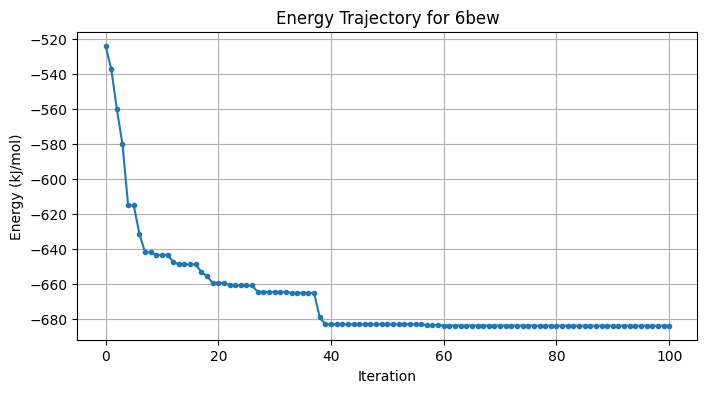

Plotting Ramachandran coordinates for Hall of Fame...


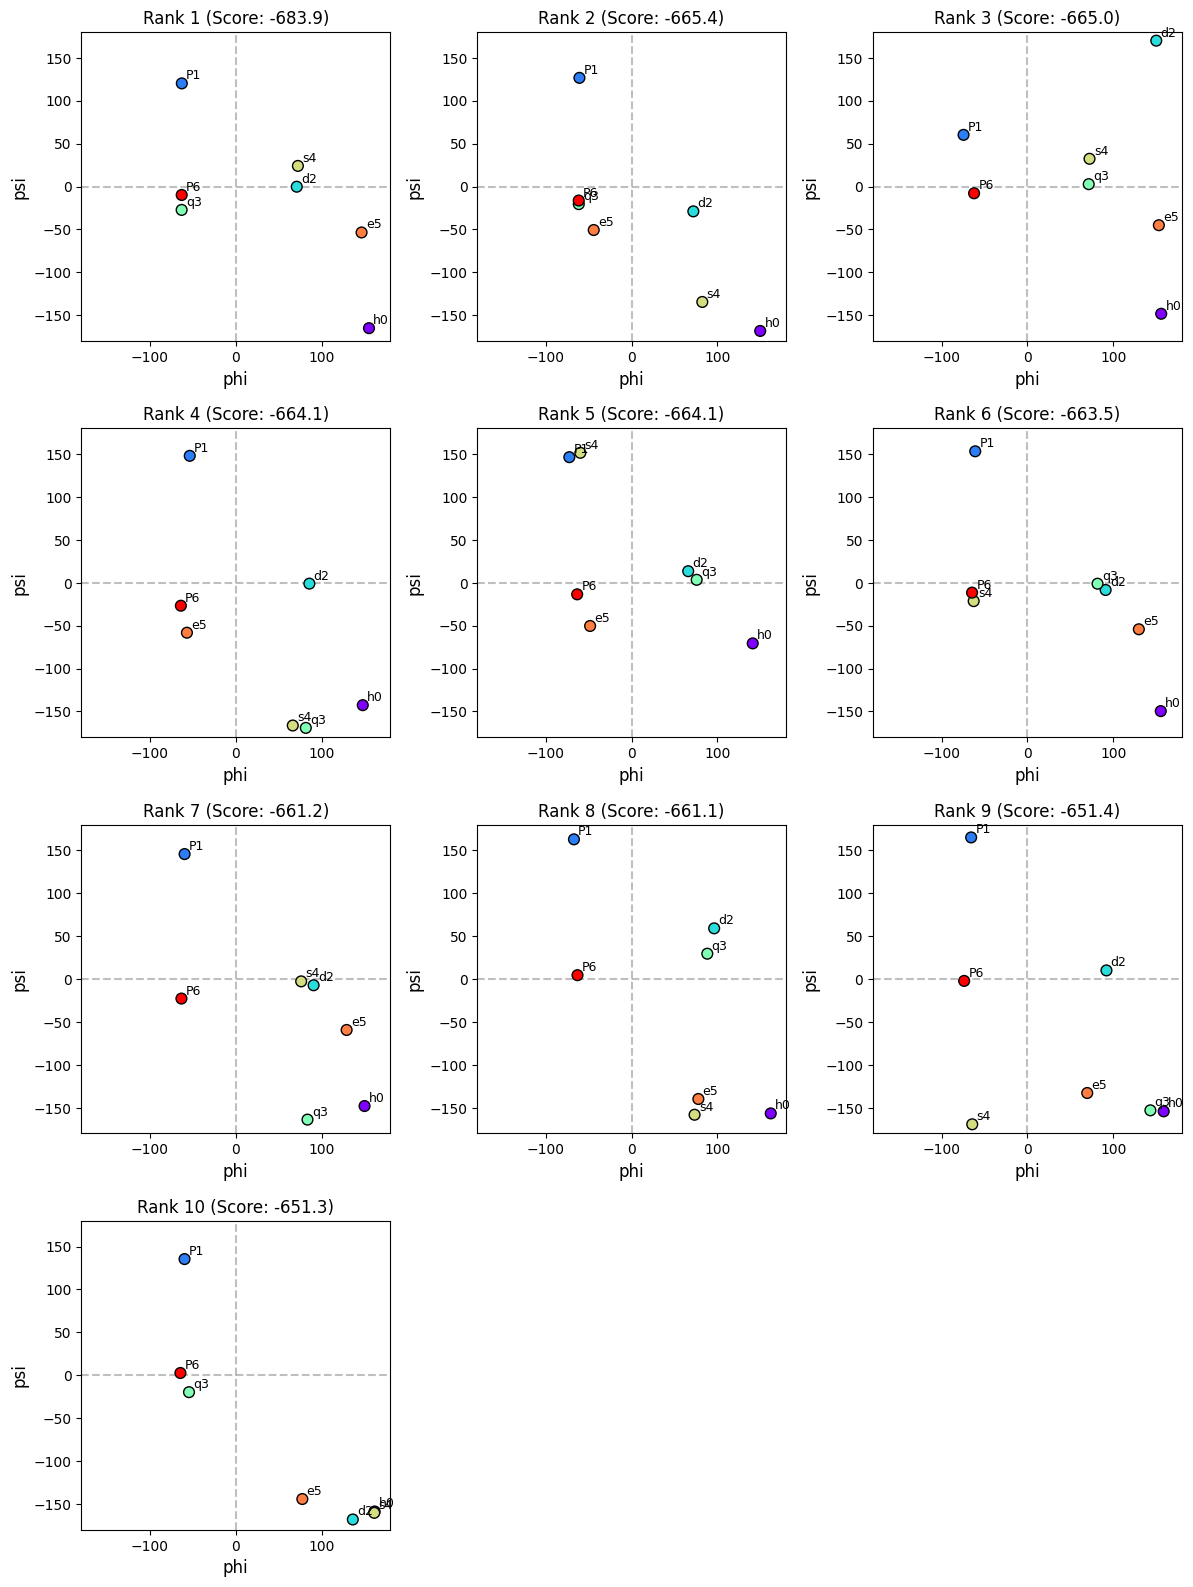

Saved best structure to 6bew_best.pdb

Optimising 6bf5 (Sequence: QDPpKtd)
Building starting macrocycle (this may take a moment for rand_mac to close the loop)...
Starting rmsd is 1.5359997502223592
At iter 19900 best rmsd is 0.06577302623307955)
Managed only rmsd of 0.06266611814908986: resampling!
At iter 10300 best rmsd is 0.05152738245168612)
After 10326 iterations and 1 attempts best rmsd is 0.049689240052808836
Setting up OpenMM context...


In [ ]:
# Test a couple of targets (e.g., the heptapeptides 7.1 and 7.2)
# You can change this list to test all of them: list(macs.keys())
test_keys = [7.1, 7.2, 7.3, 8.1, 8.2]
results = {}

for k in test_keys:
    seq = macs[k]
    pdb_id = pdbs[k]
    print(f"\n{'='*50}\nOptimising {pdb_id} (Sequence: {seq})\n{'='*50}")
    
    t1 = time.time()
    
    # 1. Initialize the optimiser
    opt = CyclicPeptideOptimiser(seq)
    
    # 2. Build start mac using ISAMBARD's rand_mac
    print("Building starting macrocycle (this may take a moment for rand_mac to close the loop)...")
    opt.build_start_mac()
    
    # 3. Setup OpenMM
    print("Setting up OpenMM context...")
    opt.amber_setup()
    
    # 4. Run the fast optimisation loop
    # Using a small number of iterations (e.g. 50) for testing speed
    n_iter = 100
    samplesize = 20
    print(f"Running optimisation for {n_iter} iterations...")
    opt.optimise(
        n_iter=n_iter,
        samplesize=samplesize,
        wp_len=20, 
        hof_len=10, 
        rama_rmsd=5, 
        n_permute=10, 
        plot=False
    )
    
    t2 = time.time()
    print(f"\nFinished {pdb_id} in {t2 - t1:.2f} seconds.")
    print(f"Initial energy: {opt.energies[0]:.2f}")
    print(f"Best energy achieved: {opt.energies[-1]:.2f}")
    
    results[k] = opt
    
    # 5. Plot the energy trajectory
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(opt.energies)), opt.energies, marker='o', markersize=3)
    plt.title(f'Energy Trajectory for {pdb_id}')
    plt.xlabel('Iteration')
    plt.ylabel('Energy (kJ/mol)')
    plt.grid(True)
    plt.show()
    
    # 6. Plot the Ramachandran grid for the Hall of Fame
    print("Plotting Ramachandran coordinates for Hall of Fame...")
    opt.plot_halloffame_ramachandran(cols=3)
    
    # 7. Save the best structure
    output_pdb = f'{pdb_id}_best.pdb'
    with open(output_pdb, 'w') as f:
        PDBFile.writeFile(opt.model.topology, opt.halloffame[0][1], file=f)
    print(f"Saved best structure to {output_pdb}")
    
    # 8. Save the full Hall of Fame
    hof_pdb = f'{pdb_id}_halloffame.pdb'
    opt.export_halloffame_pdb(hof_pdb)
    print(f"Saved full hall of fame to {hof_pdb}")
